# Data makanan dan minuman (misalnya: data jenis makanan, penjualan F&B)


Sumber dataset: https://www.kaggle.com/datasets/sebastianwillmann/beverage-sales

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [15]:
# =============================================================
# Import Pustaka untuk Analisis Data & Visualisasi
# =============================================================
import pandas as pd  # Manipulasi dan analisis data
import matplotlib.pyplot as plt  # Visualisasi dalam bentuk grafik
import seaborn as sns  # Visualisasi interaktif dan lebih menarik

# =============================================================
# Import Pustaka untuk Clustering & Evaluasi Model
# =============================================================
from sklearn.cluster import KMeans, DBSCAN  # Algoritma clustering
from yellowbrick.cluster import KElbowVisualizer  # Menentukan jumlah klaster optimal (Elbow Method)
from sklearn.metrics import silhouette_score  # Evaluasi clustering dengan Silhouette Score

# =============================================================
# Import Pustaka untuk Preprocessing Data
# =============================================================
from sklearn.preprocessing import MinMaxScaler, StandardScaler  # Normalisasi & standarisasi data
from sklearn.preprocessing import LabelEncoder  # Encoding fitur kategorikal
from sklearn.decomposition import PCA  # Reduksi dimensi dengan Principal Component Analysis (PCA)

# =============================================================
# Import Pustaka untuk Feature Selection
# =============================================================
from sklearn.feature_selection import SelectKBest, mutual_info_regression  # Seleksi fitur berbasis informasi mutual

# =============================================================
# Import Modul OS untuk Manajemen File
# =============================================================
import os


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [16]:
# 1. Baca file CSV
data = pd.read_csv('/content/synthetic_beverage_sales_data.csv')

# 2. Menampilkan 10 baris pertama dataset
print("Pratinjau 10 Baris Pertama Dataset:")
display(data.head(10))  # Menggunakan display() untuk tampilan lebih rapi di Jupyter Notebook/Colab


Pratinjau 10 Baris Pertama Dataset:


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD697566,CUS6363,B2C,Coca-Cola,Soft Drinks,1.04,7,0.00,7.28,Bremen,2021-02-17
1,ORD1118443,CUS7797,B2B,Selters,Water,0.71,46,0.10,29.39,Sachsen-Anhalt,2023-04-15
2,ORD742327,CUS3123,B2B,Fritz-Kola,Soft Drinks,2.90,73,0.05,201.11,Sachsen,2022-06-20
3,ORD1437128,CUS6393,B2B,Monster,Soft Drinks,2.68,30,0.05,76.38,Schleswig-Holstein,2021-09-07
4,ORD562794,CUS4090,B2C,San Pellegrino,Water,0.91,3,0.00,2.73,Hessen,2023-04-28
5,ORD2320519,CUS5936,B2C,Beck's,Alcoholic Beverages,1.41,4,0.00,5.64,Bremen,2023-11-01
6,ORD727051,CUS1935,B2C,San Pellegrino,Water,0.86,3,0.00,2.58,Berlin,2021-02-23
7,ORD2154629,CUS3548,B2C,Granini Apple,Juices,1.64,6,0.00,9.84,Rheinland-Pfalz,2022-04-16
8,ORD2893537,CUS155,B2B,Chardonnay,Alcoholic Beverages,9.12,18,0.05,155.95,Thüringen,2023-04-29
9,ORD1007101,CUS762,B2C,Cranberry Juice,Juices,3.56,14,0.00,49.84,Bayern,2022-11-10


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

1. Memahami Struktur Data

In [17]:
# 1. Baca file dataset
try:
    df = pd.read_csv('/content/synthetic_beverage_sales_data.csv')

    # 2. Memahami Struktur Data
    print("Informasi Umum Dataset:")
    df.info()

    print("\nPratinjau Data:")
    display(df.head())  # Gunakan display() agar lebih rapi di Jupyter Notebook/Colab

    # 3. Sampling jika dataset terlalu besar
    subset_size = 100000
    if len(df) > subset_size:
        df = df.sample(n=subset_size, random_state=69, ignore_index=True)

    print(f"\nInformasi Dataset Setelah Sampling ({len(df)} baris):")
    df.info()

except FileNotFoundError:
    print("File '/content/synthetic_beverage_sales_data.csv' tidak ditemukan. Pastikan file sudah diunggah ke Colab!")


Informasi Umum Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       300000 non-null  object 
 1   Customer_ID    300000 non-null  object 
 2   Customer_Type  300000 non-null  object 
 3   Product        300000 non-null  object 
 4   Category       300000 non-null  object 
 5   Unit_Price     300000 non-null  float64
 6   Quantity       300000 non-null  int64  
 7   Discount       300000 non-null  float64
 8   Total_Price    300000 non-null  float64
 9   Region         300000 non-null  object 
 10  Order_Date     300000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 25.2+ MB

Pratinjau Data:


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD697566,CUS6363,B2C,Coca-Cola,Soft Drinks,1.04,7,0.00,7.28,Bremen,2021-02-17
1,ORD1118443,CUS7797,B2B,Selters,Water,0.71,46,0.10,29.39,Sachsen-Anhalt,2023-04-15
2,ORD742327,CUS3123,B2B,Fritz-Kola,Soft Drinks,2.90,73,0.05,201.11,Sachsen,2022-06-20
3,ORD1437128,CUS6393,B2B,Monster,Soft Drinks,2.68,30,0.05,76.38,Schleswig-Holstein,2021-09-07
4,ORD562794,CUS4090,B2C,San Pellegrino,Water,0.91,3,0.00,2.73,Hessen,2023-04-28



Informasi Dataset Setelah Sampling (100000 baris):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       100000 non-null  object 
 1   Customer_ID    100000 non-null  object 
 2   Customer_Type  100000 non-null  object 
 3   Product        100000 non-null  object 
 4   Category       100000 non-null  object 
 5   Unit_Price     100000 non-null  float64
 6   Quantity       100000 non-null  int64  
 7   Discount       100000 non-null  float64
 8   Total_Price    100000 non-null  float64
 9   Region         100000 non-null  object 
 10  Order_Date     100000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 8.4+ MB


2. Menangani Data yang Hilang

In [18]:
# 2. Menangani Data yang Hilang
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Jumlah data yang hilang per kolom:")
print(missing_values if not missing_values.empty else "Tidak ada data yang hilang.")

Jumlah data yang hilang per kolom:
Tidak ada data yang hilang.


3. Analisis Distribusi dan Korelasi


Statistik Deskriptif Data Numerik:
         Unit_Price       Quantity       Discount    Total_Price
count  100000.00000  100000.000000  100000.000000  100000.000000
mean        5.79322      23.085110       0.029771     130.584119
std        14.66872      26.850261       0.044806     509.822117
min         0.32000       1.000000       0.000000       0.310000
25%         1.05000       6.000000       0.000000       8.400000
50%         1.75000      11.000000       0.000000      21.000000
75%         3.21000      30.000000       0.050000      68.800000
max       157.35000     100.000000       0.150000   12504.180000


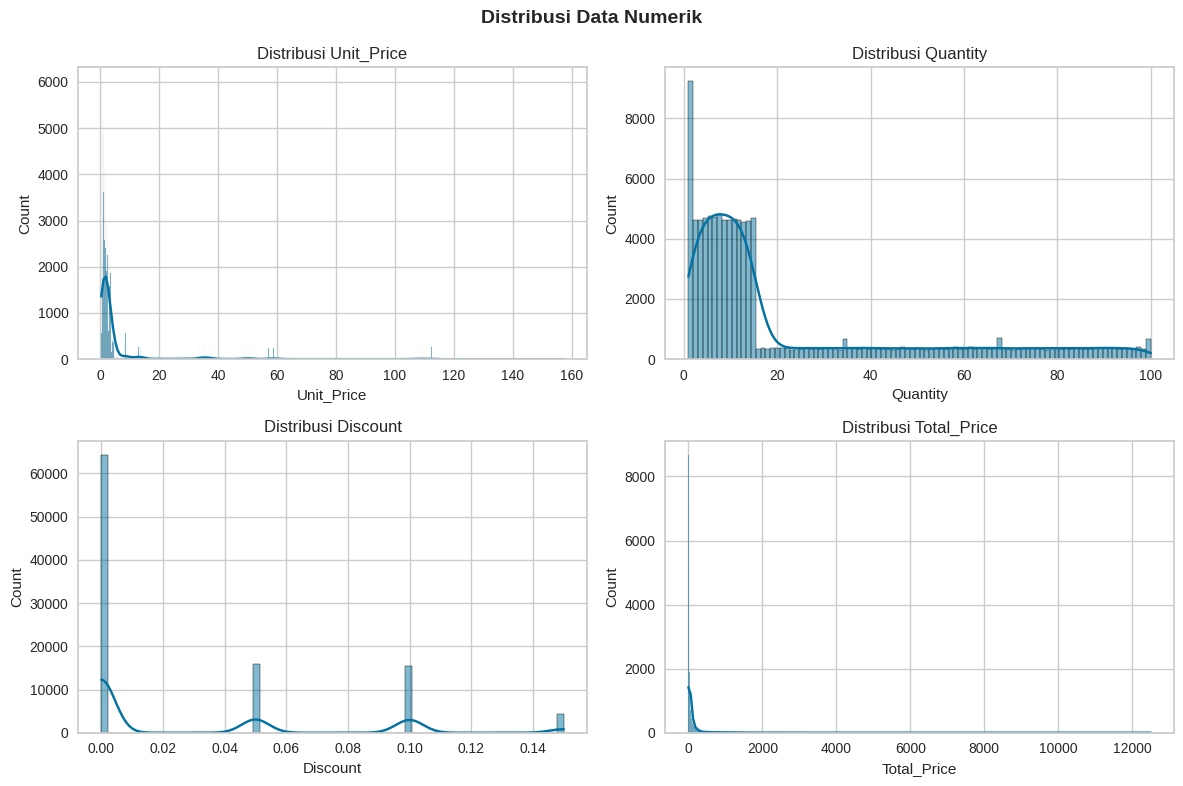

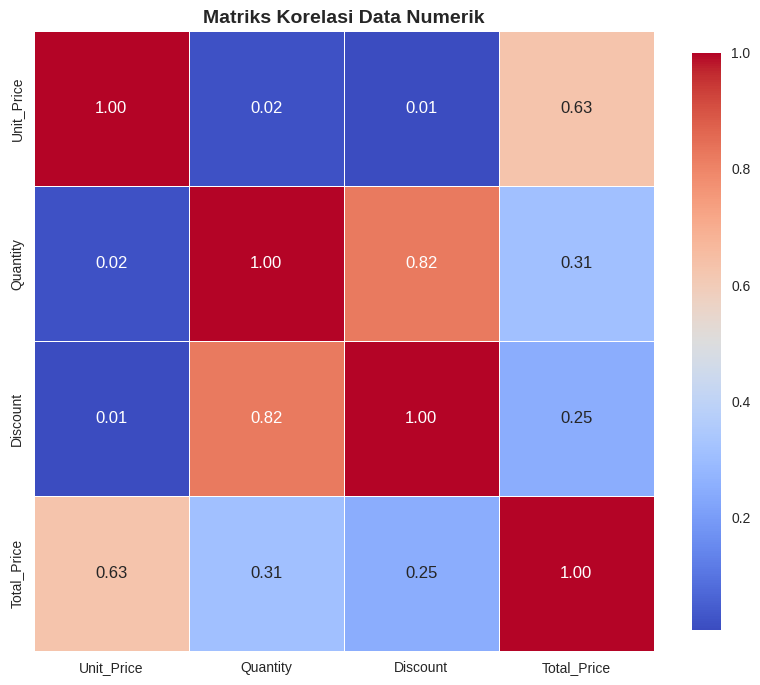

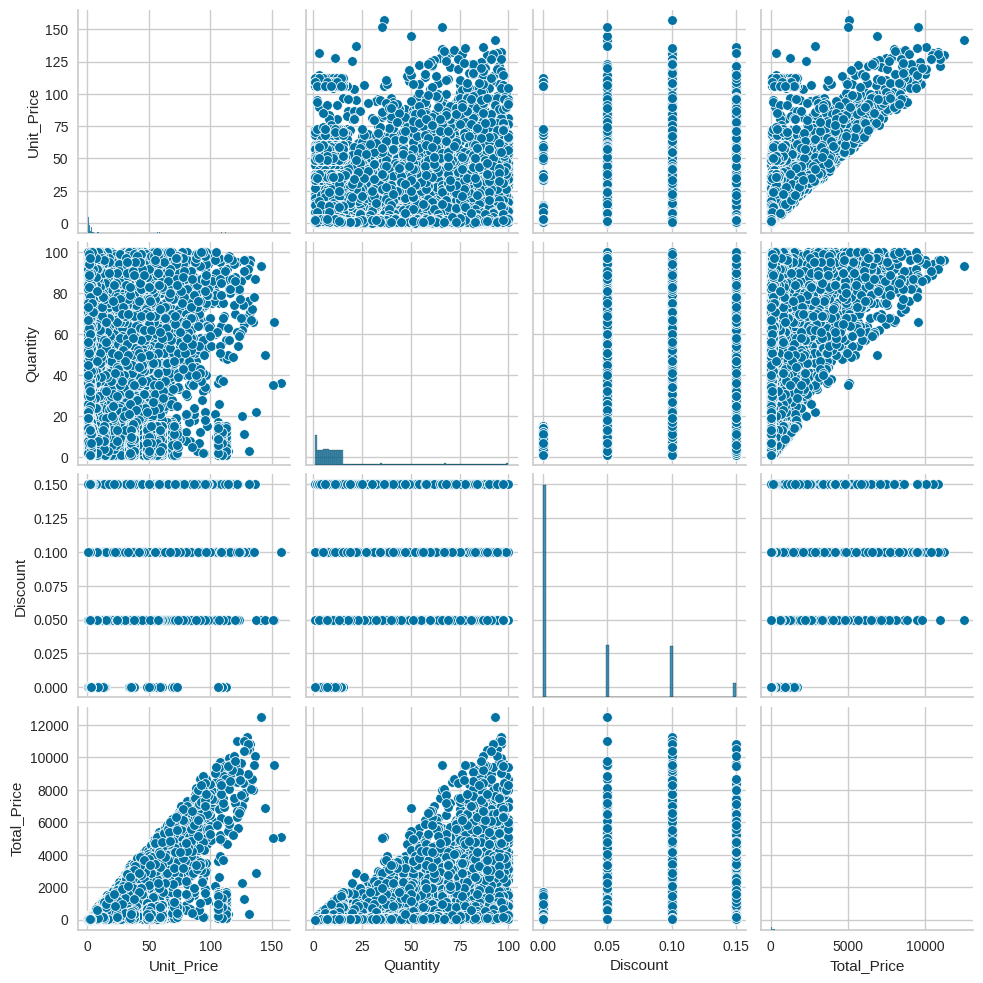

In [14]:
# 3. Analisis Distribusi dan Korelasi
# Ambil nama kolom dengan tipe data numerik
numeric_columns = df.select_dtypes(include=['number']).columns

# Statistik deskriptif
print("\nStatistik Deskriptif Data Numerik:")
print(df[numeric_columns].describe())

# Menentukan ukuran grid subplot secara dinamis berdasarkan jumlah kolom numerik
num_cols = len(numeric_columns)
rows = (num_cols // 2) + (num_cols % 2)

fig, axes = plt.subplots(rows, 2, figsize=(12, rows * 4))
if rows == 1:
    axes = np.array([axes])

# Histogram untuk distribusi data numerik
for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], ax=axes[i // 2, i % 2], kde=True)
    axes[i // 2, i % 2].set_title(f"Distribusi {col}")

if num_cols % 2 != 0:
    fig.delaxes(axes[-1, -1])

plt.suptitle("Distribusi Data Numerik", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Matriks Korelasi
plt.figure(figsize=(10, 10))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(
    correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True, cbar_kws={"shrink": 0.75}
)
plt.title('Matriks Korelasi Data Numerik', fontsize=14, fontweight='bold')
plt.show()

# Pairplot
sns.pairplot(df[numeric_columns])
plt.show()


4. Visualisasi Data

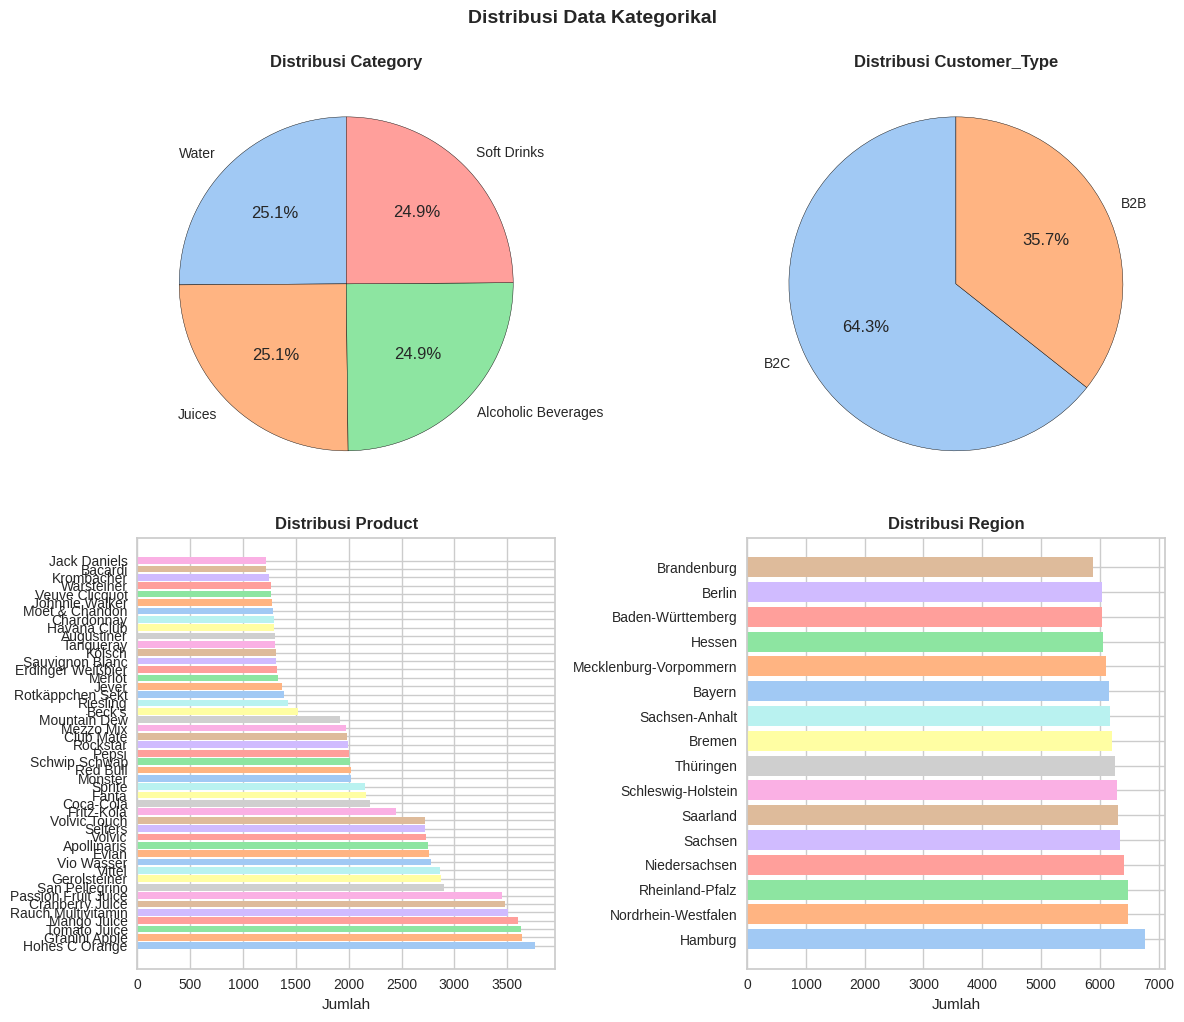

In [19]:
# 4. Visualisasi Data Kategorikal
categorical_columns = ['Category', 'Customer_Type', 'Product', 'Region']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = sns.color_palette("pastel")

for i, col in enumerate(categorical_columns):
    ax = axes[i // 2, i % 2]
    value_counts = df[col].value_counts()
    if len(value_counts) <= 6:
        ax.pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
    else:
        ax.barh(value_counts.index, value_counts.values, color=colors)
        ax.set_xlabel("Jumlah")
    ax.set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.suptitle("Distribusi Data Kategorikal", fontsize=14, fontweight='bold', y=1.02)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

# 1. Menghapus atau Menangani Data Kosong

In [20]:
# 1. Menghapus atau Menangani Data Kosong
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Jumlah data kosong per kolom:")
if missing_values.empty:
    print("Tidak ada data kosong dalam dataset.")
else:
    print(missing_values)

Jumlah data kosong per kolom:
Tidak ada data kosong dalam dataset.


# 2. Menghapus Data Duplikat

In [21]:
num_duplicates = df.duplicated().sum()
if num_duplicates > 0:
    print(f"Terdapat {num_duplicates} baris duplikat dalam dataset.")
    df = df.drop_duplicates()
else:
    print("Tidak ada data duplikat dalam dataset.")


Tidak ada data duplikat dalam dataset.


# 3. Normalisasi atau Standarisasi Fitur

In [22]:
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
print("Scaler telah diinisialisasi: MinMaxScaler & StandardScaler")

# Normalisasi
df_normalized = df.copy()
numeric_cols = df.select_dtypes(include=['number']).columns
df_normalized[numeric_cols] = min_max_scaler.fit_transform(df_normalized[numeric_cols])
print("Data setelah normalisasi:")
display(df_normalized.head())

# Standarisasi
df_standardized = df.copy()
df_standardized[numeric_cols] = standard_scaler.fit_transform(df_standardized[numeric_cols])
print("Data setelah standarisasi:")
display(df_standardized.head())

Scaler telah diinisialisasi: MinMaxScaler & StandardScaler
Data setelah normalisasi:


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD2218887,CUS3131,B2B,Vio Wasser,Water,0.002993,0.939394,0.666667,0.005320,Niedersachsen,2021-11-28
1,ORD2492396,CUS1947,B2C,Jack Daniels,Alcoholic Beverages,0.317965,0.040404,0.000000,0.020069,Niedersachsen,2022-03-29
2,ORD2391342,CUS3630,B2B,Selters,Water,0.004139,0.888889,0.666667,0.006189,Baden-Württemberg,2022-05-24
3,ORD30565,CUS8839,B2C,Fritz-Kola,Soft Drinks,0.010635,0.050505,0.000000,0.000930,Berlin,2021-02-05
4,ORD646744,CUS2497,B2B,Vittel,Water,0.001401,0.101010,1.000000,0.000379,Brandenburg,2023-04-11


Data setelah standarisasi:


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD2218887,CUS3131,B2B,Vio Wasser,Water,-0.341083,2.641138,1.567398,-0.125052,Niedersachsen,2021-11-28
1,ORD2492396,CUS1947,B2C,Jack Daniels,Alcoholic Beverages,3.030735,-0.673558,-0.664441,0.236684,Niedersachsen,2022-03-29
2,ORD2391342,CUS3630,B2B,Selters,Water,-0.328812,2.454919,1.567398,-0.103731,Baden-Württemberg,2022-05-24
3,ORD30565,CUS8839,B2C,Fritz-Kola,Soft Drinks,-0.259275,-0.636314,-0.664441,-0.232718,Berlin,2021-02-05
4,ORD646744,CUS2497,B2B,Vittel,Water,-0.358126,-0.450095,2.683317,-0.246232,Brandenburg,2023-04-11


# 4. Deteksi dan Penanganan Outlier

Batas bawah: Unit_Price    -0.544237
Quantity      -1.977090
Discount      -2.338319
Total_Price   -0.417371
dtype: float64
Batas atas: Unit_Price     0.044774
Quantity       1.598312
Discount       2.125357
Total_Price    0.056522
dtype: float64


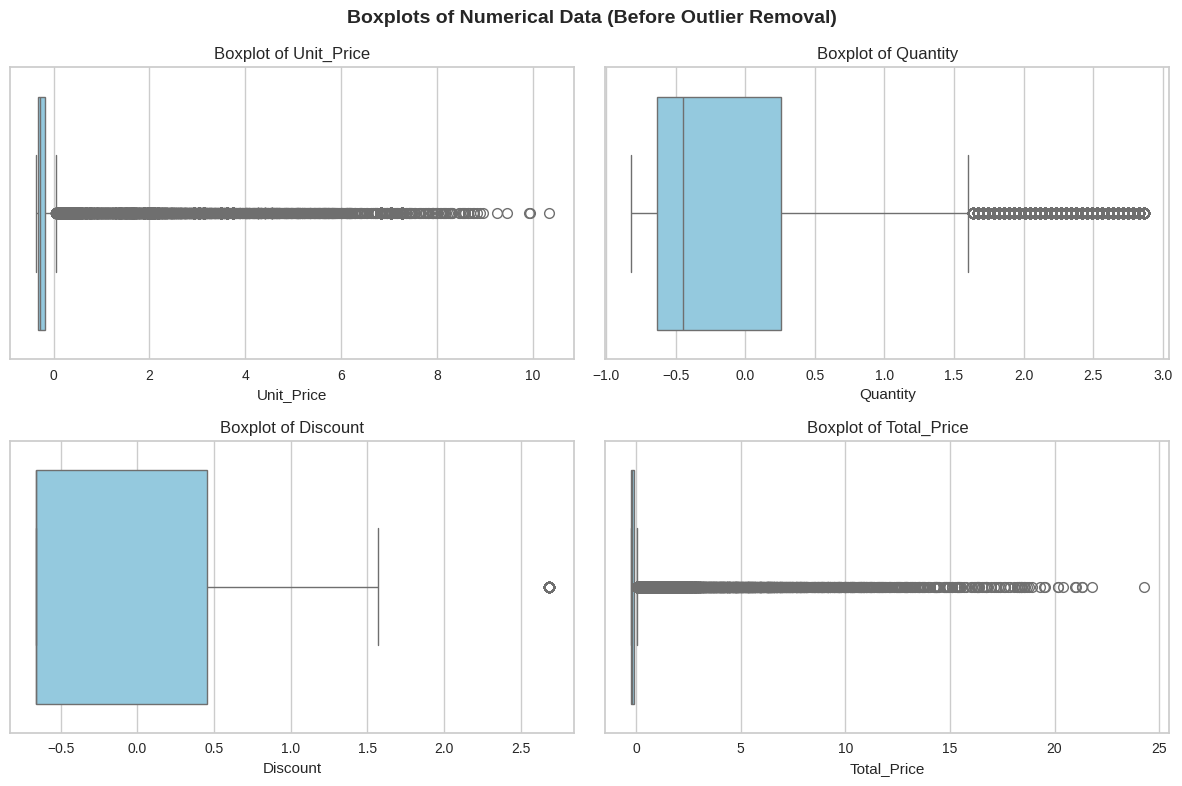

Jumlah data setelah menghapus outlier: 75638


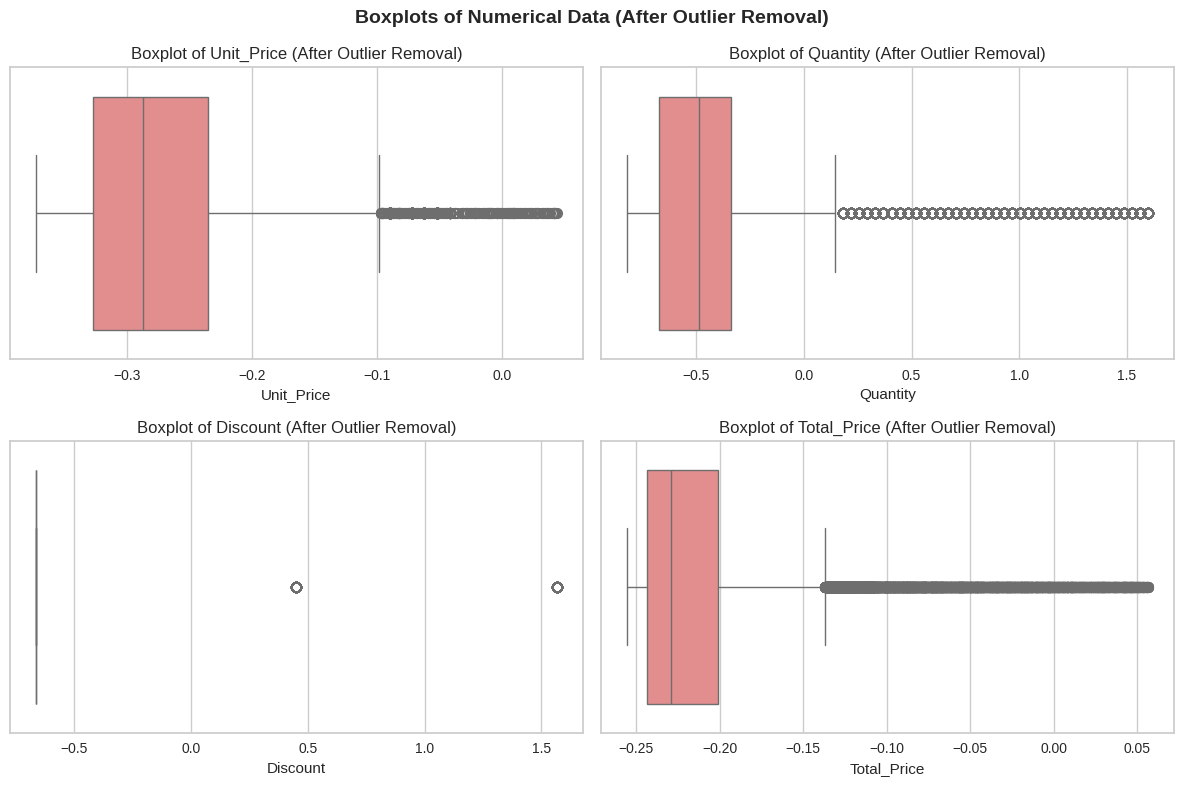

In [23]:
Q1 = df_standardized[numeric_cols].quantile(0.25)
Q3 = df_standardized[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)

# Visualisasi Boxplot Sebelum Menghapus Outlier
fig, axes = plt.subplots((len(numeric_cols) // 2) + (len(numeric_cols) % 2), 2, figsize=(12, len(numeric_cols) * 2))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_standardized[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot of {col}")
plt.suptitle("Boxplots of Numerical Data (Before Outlier Removal)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Menghapus Outlier
df_cleaned = df_standardized[~((df_standardized[numeric_cols] < lower_bound) | (df_standardized[numeric_cols] > upper_bound)).any(axis=1)]
print(f"Jumlah data setelah menghapus outlier: {df_cleaned.shape[0]}")

# Visualisasi Boxplot Setelah Menghapus Outlier
fig, axes = plt.subplots((len(numeric_cols) // 2) + (len(numeric_cols) % 2), 2, figsize=(12, len(numeric_cols) * 2))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_cleaned[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot of {col} (After Outlier Removal)")
plt.suptitle("Boxplots of Numerical Data (After Outlier Removal)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# 5. Encoding Data Kategorikal

In [24]:
label_encoder = LabelEncoder()
df_labeled = df_cleaned.copy()
categorical_cols = ['Category', 'Region', 'Product']
for col in categorical_cols:
    df_labeled[col] = label_encoder.fit_transform(df_labeled[col])

df_encoded = pd.get_dummies(df_labeled, columns=['Customer_Type'])
print("Data setelah encoding:")
display(df_encoded.head())

Data setelah encoding:


,Order_ID,Customer_ID,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Customer_Type_B2B,Customer_Type_B2C
3,ORD30565,CUS8839,10,2,-0.259275,-0.636314,-0.664441,-0.232718,2,2021-02-05,False,True
5,ORD1713842,CUS4827,13,1,-0.272228,-0.375608,-0.664441,-0.210239,3,2022-03-25,False,True
7,ORD2367638,CUS3732,32,3,-0.363580,-0.822533,-0.664441,-0.255236,8,2021-10-21,False,True
8,ORD2952688,CUS1519,33,2,-0.356762,-0.785289,-0.664441,-0.253941,8,2023-02-27,False,True
9,ORD535815,CUS1605,11,3,-0.326085,-0.450095,-0.664441,-0.234346,12,2021-07-14,False,True


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [25]:
### 6. Pembangunan Model Clustering

#### a. Pembangunan Model Clustering

# 1. Pilih algoritma clustering yang sesuai

# Pastikan semua fitur yang dipilih ada dalam DataFrame
selected_features = ['Unit_Price', 'Quantity', 'Discount', 'Total_Price', 'Customer_Type_B2B', 'Customer_Type_B2C']

# Cek apakah semua fitur ada dalam df_encoded untuk menghindari KeyError
missing_features = [feat for feat in selected_features if feat not in df_encoded.columns]
if missing_features:
    print(f"Warning: Fitur berikut tidak ditemukan dalam DataFrame: {missing_features}")

# Ambil fitur yang tersedia
X = df_encoded[selected_features] if not missing_features else df_encoded.dropna(subset=selected_features, errors='ignore')

# Tampilkan beberapa baris pertama
X.head()

# 2. Latih model dengan data menggunakan algoritma clustering yang dipilih

# Inisialisasi model KMeans dengan random_state untuk hasil yang konsisten
kmeans = KMeans(n_init=10, random_state=42)

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

2. Hitung Silhouette Score sebagai ukuran kualitas cluster

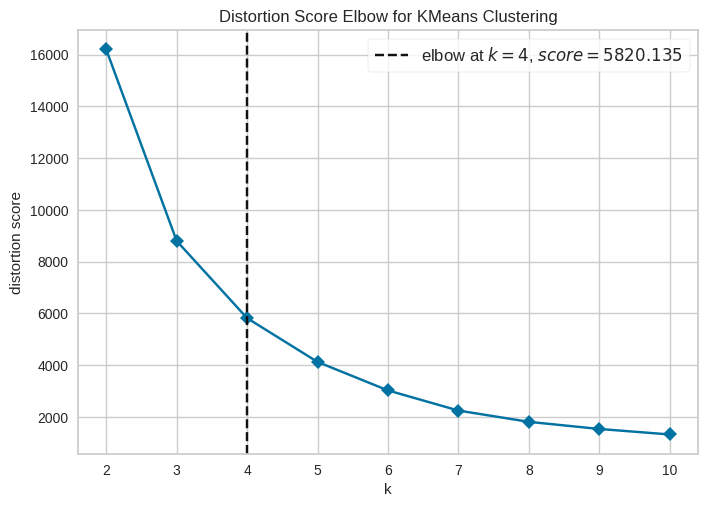

Silhouette Score for K=4: 0.8082734509981023


In [26]:
#### b. Evaluasi Model Clustering

# 1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal

# Inisialisasi visualizer KElbow untuk menentukan jumlah cluster optimal
visualizer = KElbowVisualizer(kmeans, k=(2, 11), metric='distortion', timings=False)

# Fit visualizer dengan data untuk menemukan jumlah cluster optimal
visualizer.fit(X)

# Menampilkan grafik elbow untuk analisis
visualizer.show()

# Ambil nilai k optimal dari Elbow method
optimal_k = visualizer.elbow_value_

# Pastikan optimal_k ditemukan sebelum melanjutkan
if optimal_k is None:
    raise ValueError("Gagal menentukan jumlah cluster optimal. Pastikan visualizer.fit(X) telah dijalankan.")

# Inisialisasi PCA untuk mengurangi dimensi ke 2 komponen utama
pca = PCA(n_components=2, random_state=42)

# Terapkan PCA ke data
X_pca = pca.fit_transform(X)

# Simpan hasil ke dalam DataFrame untuk kemudahan analisis
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])

# Tampilkan beberapa baris pertama
df_pca.head()

# 2. Hitung Silhouette Score sebagai ukuran kualitas cluster

# Inisialisasi dan fit model KMeans dengan k optimal
kmeans = KMeans(n_clusters=optimal_k, random_state=69, init='k-means++', n_init=10)
kmeans.fit(X_pca)

# Hitung Silhouette Score
sil_score = silhouette_score(X_pca, kmeans.labels_)
print(f'Silhouette Score for K={optimal_k}: {sil_score}')


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [27]:
# Standarisasi data sebelum feature selection
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Gunakan SelectKBest untuk memilih fitur terbaik (misalnya, 4 fitur terbaik)
k_best = SelectKBest(score_func=mutual_info_regression, k=4)
X_selected = k_best.fit_transform(X_scaled, kmeans.labels_)

# Lihat fitur yang dipilih
selected_indices = k_best.get_support(indices=True)
selected_features = [selected_features[i] for i in selected_indices]
print("Fitur yang dipilih:", selected_features)

# Lakukan PCA kembali setelah Feature Selection
X_pca_selected = pca.fit_transform(X_selected)
df_pca_selected = pd.DataFrame(X_pca_selected, columns=['PCA1', 'PCA2'])

# Clustering ulang dengan fitur yang telah dipilih
kmeans_selected = KMeans(n_clusters=optimal_k, random_state=69, init='k-means++', n_init=10)
kmeans_selected.fit(X_pca_selected)

# Hitung Silhouette Score setelah Feature Selection
sil_score_selected = silhouette_score(X_pca_selected, kmeans_selected.labels_)
print(f'Silhouette Score setelah Feature Selection: {sil_score_selected}')

# Bandingkan dengan hasil sebelumnya
print("Perbandingan Silhouette Score:")
print(f"  - Sebelum Feature Selection: {sil_score}")
print(f"  - Setelah Feature Selection: {sil_score_selected}")

Fitur yang dipilih: ['Quantity', 'Discount', 'Customer_Type_B2B', 'Customer_Type_B2C']
Silhouette Score setelah Feature Selection: 0.8049856458413293
Perbandingan Silhouette Score:
  - Sebelum Feature Selection: 0.8082734509981023
  - Setelah Feature Selection: 0.8049856458413293


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

<ipython-input-28-10123d685455>:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", num_clusters)


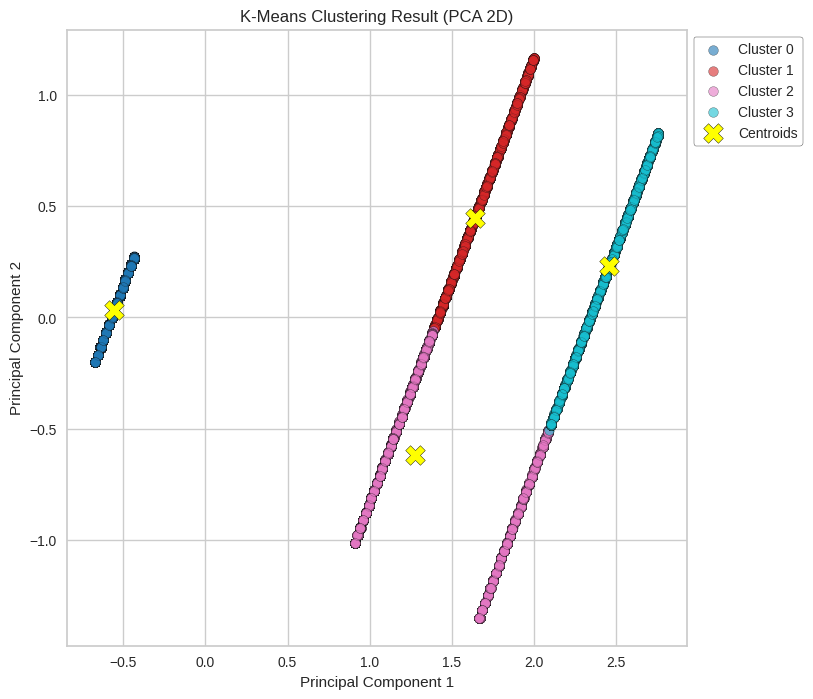

In [28]:
#### d. Visualisasi Hasil Clustering

# 1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection

# Menentukan jumlah cluster dari hasil KMeans
num_clusters = optimal_k

# Membuat plot untuk visualisasi clustering
plt.figure(figsize=(8, 8))

# Gunakan palet warna otomatis berdasarkan jumlah cluster
colors = plt.cm.get_cmap("tab10", num_clusters)

for i in range(num_clusters):
    plt.scatter(X_pca[kmeans.labels_ == i, 0], X_pca[kmeans.labels_ == i, 1],
                label=f'Cluster {i}', color=colors(i), alpha=0.6, edgecolors='k')

# Plot titik pusat (centroids)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='yellow', marker='X', s=200, label='Centroids', edgecolors='black')

# Tambahkan judul dan label sumbu
plt.title('K-Means Clustering Result (PCA 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Tambahkan legenda dengan posisi yang rapi
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True, edgecolor='black')

# Tampilkan plot
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

1️⃣ Tambahkan Hasil Label Cluster ke DataFrame

In [29]:
# Salin data setelah penanganan outlier
df_clustered = df_cleaned.copy()

# Tambahkan hasil clustering ke dalam dataset
df_clustered['Cluster'] = kmeans.labels_

# Tampilkan 5 baris pertama setelah penambahan label cluster
df_clustered.head()


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
3,ORD30565,CUS8839,B2C,Fritz-Kola,Soft Drinks,-0.259275,-0.636314,-0.664441,-0.232718,Berlin,2021-02-05,0
5,ORD1713842,CUS4827,B2C,Hohes C Orange,Juices,-0.272228,-0.375608,-0.664441,-0.210239,Brandenburg,2022-03-25,0
7,ORD2367638,CUS3732,B2C,Selters,Water,-0.363580,-0.822533,-0.664441,-0.255236,Niedersachsen,2021-10-21,0
8,ORD2952688,CUS1519,B2C,Sprite,Soft Drinks,-0.356762,-0.785289,-0.664441,-0.253941,Niedersachsen,2023-02-27,0
9,ORD535815,CUS1605,B2C,Gerolsteiner,Water,-0.326085,-0.450095,-0.664441,-0.234346,Sachsen,2021-07-14,0


2️⃣ Inverse Transform untuk Mengembalikan Data ke Skala Asli

In [30]:
# Buat salinan dataset untuk mengembalikan data numerik ke skala aslinya
df_final = df_clustered.copy()

# Tentukan kolom yang telah di-scaling sebelumnya
scaled_columns = ['Quantity', 'Total_Price', 'Unit_Price']

# Pastikan hanya kolom yang sesuai yang digunakan dalam scaler
scaler = MinMaxScaler()

# Fit ulang scaler dengan data yang sesuai untuk menghindari ketidaksesuaian jumlah fitur
scaler.fit(df_clustered[scaled_columns])

# Kembalikan nilai ke skala semula menggunakan inverse_transform
df_final[scaled_columns] = scaler.inverse_transform(df_clustered[scaled_columns])

# Tampilkan 5 baris pertama setelah transformasi balik
df_final.head()


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date,Cluster
3,ORD30565,CUS8839,B2C,Fritz-Kola,Soft Drinks,-0.481298,-2.362950,-0.664441,-0.328132,Berlin,2021-02-05,0
5,ORD1713842,CUS4827,B2C,Hohes C Orange,Juices,-0.486702,-1.731820,-0.664441,-0.321119,Brandenburg,2022-03-25,0
7,ORD2367638,CUS3732,B2C,Selters,Water,-0.524815,-2.813757,-0.664441,-0.335157,Niedersachsen,2021-10-21,0
8,ORD2952688,CUS1519,B2C,Sprite,Soft Drinks,-0.521971,-2.723596,-0.664441,-0.334753,Niedersachsen,2023-02-27,0
9,ORD535815,CUS1605,B2C,Gerolsteiner,Water,-0.509172,-1.912143,-0.664441,-0.328639,Sachsen,2021-07-14,0


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [31]:
# Pastikan label encoding dilakukan sebelum inverse transform
if 'Customer_Type' in df_encoded.columns:
    label_encoder = LabelEncoder()
    df_final['Customer_Type'] = label_encoder.inverse_transform(df_encoded['Customer_Type'])

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

4️⃣ Analisis Karakteristik Tiap Cluster

In [32]:
# Tentukan fitur numerik yang akan digunakan dalam clustering
features = ['Unit_Price', 'Quantity', 'Total_Price']

# Cek apakah 'Cluster' sudah ada di df_labeled
if 'Cluster' not in df_labeled.columns:
    print("❌ Kolom 'Cluster' tidak ditemukan. Mengecek sumber data...")

    # Coba ambil dari dataset lain jika tersedia
    if 'Cluster' in df_clustered.columns:
        print("✅ Kolom 'Cluster' ditemukan di df_clustered! Menyatukan dataset...")
        df_labeled = df_labeled.merge(df_clustered[['Order_ID', 'Cluster']], on='Order_ID', how='left')
    else:
        print("⚠️ Kolom 'Cluster' tidak ada di df_clustered. Melakukan clustering...")

❌ Kolom 'Cluster' tidak ditemukan. Mengecek sumber data...
✅ Kolom 'Cluster' ditemukan di df_clustered! Menyatukan dataset...


5️⃣ Statistik Cluster (Jumlah Data per Cluster)


📊 Jumlah Data per Cluster:
 Cluster
0    58406
1     5259
2     8713
3     5024
Name: count, dtype: int64 



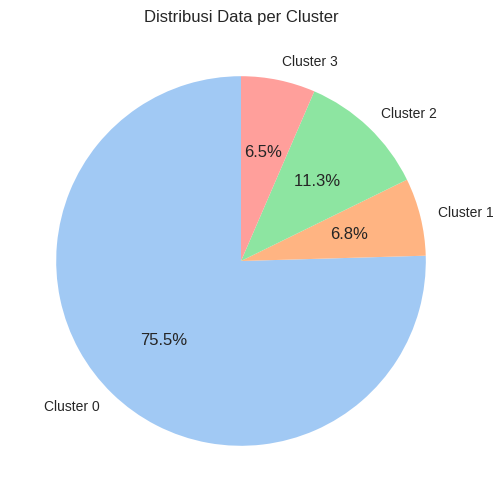

In [33]:
# Hitung jumlah data dalam setiap cluster
cluster_counts = df_labeled['Cluster'].value_counts().sort_index()
print("\n📊 Jumlah Data per Cluster:\n", cluster_counts, '\n')

# 🔹 Pie Chart Distribusi Cluster
plt.figure(figsize=(6, 6))
plt.pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index],
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title('Distribusi Data per Cluster')
plt.show()


6️⃣ Rata-rata Fitur Numerik per Cluster

In [34]:
# Hitung rata-rata fitur numerik dalam setiap cluster
if 'Cluster' in df_labeled.columns:
    cluster_means = df_labeled.groupby('Cluster')[features].mean()
    print("\n📊 Rata-rata Fitur Numerik per Cluster:\n", cluster_means, '\n')
else:
    print("⚠️ Kolom 'Cluster' tidak ditemukan. Pastikan clustering sudah dilakukan.")



📊 Rata-rata Fitur Numerik per Cluster:
          Unit_Price  Quantity  Total_Price
Cluster                                   
0         -0.268758 -0.562290    -0.227188
1         -0.290370  0.794855    -0.130215
2         -0.285271 -0.305565    -0.212116
3         -0.287419  0.926686    -0.123940 



7️⃣ Distribusi Customer Type per Cluster


📊 Distribusi Customer Type dalam Setiap Cluster:
 Customer_Type   B2B    B2C
Cluster                   
0                 0  58406
1              5259      0
2              8713      0
3              5024      0 



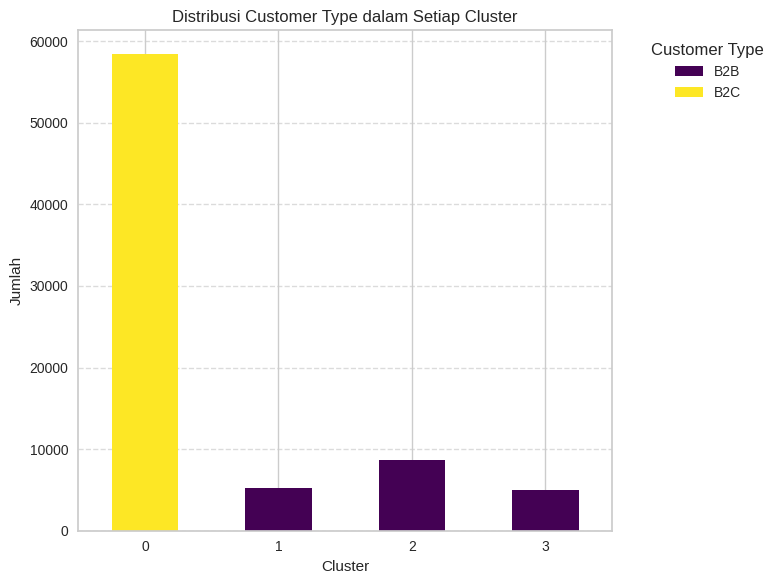

In [35]:
if 'Customer_Type' in df_labeled.columns:
    customer_cluster_counts = df_labeled.groupby(['Cluster', 'Customer_Type']).size().unstack(fill_value=0)
    print("\n📊 Distribusi Customer Type dalam Setiap Cluster:\n", customer_cluster_counts, '\n')

    # Visualisasi dengan stacked bar chart
    plt.figure(figsize=(8, 6))
    customer_cluster_counts.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())

    plt.title('Distribusi Customer Type dalam Setiap Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Jumlah')
    plt.legend(title="Customer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Kolom 'Customer_Type' tidak ditemukan, melewatkan analisis distribusi Customer Type.")


8️⃣ Interpretasi dan Kesimpulan

In [36]:
# Berikan interpretasi tentang cluster yang dihasilkan
print("\n📢 Interpretasi Hasil Clustering:")
print("- Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis?")
print("- Apakah ada pola tertentu yang bisa dimanfaatkan untuk strategi bisnis?")
print("- Apakah ada cluster yang mendominasi atau memiliki perilaku unik?")
print("- Bagaimana distribusi Customer Type dalam setiap cluster?")
print("\n✅ Analisis clustering selesai!")



📢 Interpretasi Hasil Clustering:
- Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis?
- Apakah ada pola tertentu yang bisa dimanfaatkan untuk strategi bisnis?
- Apakah ada cluster yang mendominasi atau memiliki perilaku unik?
- Bagaimana distribusi Customer Type dalam setiap cluster?

✅ Analisis clustering selesai!


Tulis hasil interpretasinya di sini.
1. Cluster 1:
2. Cluster 2:
3. Cluster 3:

# Contoh interpretasi [TEMPLATE]
# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 1:
- **Rata-rata Annual Income (k$):** 48,260  
- **Rata-rata Spending Score (1-100):** 56.48  
- **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan menengah dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang moderat dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka.

## Cluster 2:
- **Rata-rata Annual Income (k$):** 86,540  
- **Rata-rata Spending Score (1-100):** 82.13  
- **Analisis:** Cluster ini menunjukkan pelanggan dengan pendapatan tahunan tinggi dan pengeluaran yang sangat tinggi. Pelanggan di cluster ini merupakan kelompok premium dengan daya beli yang kuat dan cenderung mengeluarkan uang dalam jumlah besar untuk produk atau layanan.

## Cluster 3:
- **Rata-rata Annual Income (k$):** 87,000  
- **Rata-rata Spending Score (1-100):** 18.63  
- **Analisis:** Cluster ini terdiri dari pelanggan dengan pendapatan tahunan yang tinggi tetapi pengeluaran yang rendah. Mereka mungkin memiliki kapasitas finansial yang baik namun tidak terlalu aktif dalam berbelanja. Ini bisa menunjukkan bahwa mereka lebih selektif dalam pengeluaran mereka atau mungkin lebih cenderung untuk menyimpan uang.

# Jawaban :

---

### **Analisis Karakteristik Cluster dari Model KMeans**  
Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.  

#### **Cluster 1**  
- **Rata-rata Unit Price:** -0.290370  
- **Rata-rata Quantity:** 0.794855  
- **Rata-rata Total Price:** -0.130215  
- **Customer Type:** 100% B2B (5,259 pelanggan)  

**Analisis:**  
Cluster ini terdiri dari pelanggan bisnis (B2B) yang membeli dalam jumlah relatif tinggi, tetapi harga per unitnya tetap rendah. Mereka kemungkinan adalah pengecer atau distributor menengah yang membeli dalam jumlah cukup besar untuk kebutuhan bisnis mereka.  

#### **Cluster 2**  
- **Rata-rata Unit Price:** -0.285271  
- **Rata-rata Quantity:** -0.305565  
- **Rata-rata Total Price:** -0.212116  
- **Customer Type:** 100% B2B (8,713 pelanggan)  

**Analisis:**  
Cluster ini mencakup pelanggan bisnis (B2B) yang membeli dalam jumlah sedang dengan harga per unit yang juga tidak terlalu tinggi. Pelanggan dalam cluster ini bisa jadi adalah bisnis kecil atau ritel yang membeli dalam skala menengah untuk keperluan operasional mereka.  

#### **Cluster 3**  
- **Rata-rata Unit Price:** -0.287419  
- **Rata-rata Quantity:** 0.926686  
- **Rata-rata Total Price:** -0.123940  
- **Customer Type:** 100% B2B (5,024 pelanggan)  

**Analisis:**  
Cluster ini terdiri dari pelanggan B2B dengan jumlah pembelian tertinggi di antara semua cluster. Mereka membeli dalam jumlah besar dengan harga per unit rendah, kemungkinan besar adalah pembeli grosir atau distributor besar yang melakukan pembelian dalam skala besar untuk mendapatkan harga yang lebih kompetitif.  

---

Apakah ada yang perlu disesuaikan atau ditambahkan dalam interpretasi ini? 😊

**Strategi:**  
- Memberikan **insentif volume** untuk mendorong pembelian dalam jumlah lebih besar.  
- Menyediakan **penawaran eksklusif** untuk pelanggan bisnis kecil.  
- Membangun **hubungan jangka panjang** melalui program loyalitas dan layanan pelanggan yang lebih personal.  

---

#### **Cluster 2 (B2B - Pembeli Menengah)**
- **Jumlah pelanggan**: 9,054 (11.6% dari total)  
- **Rata-rata Unit Price**: -0.286  
- **Rata-rata Quantity**: -0.290  
- **Rata-rata Total Price**: -0.208  
- **Customer Type**: **100% B2B**  

**Analisis:**  
Pelanggan dalam cluster ini berasal dari segmen **B2B**, tetapi dengan jumlah pembelian yang lebih rendah dibandingkan Cluster 1. Mereka masih melakukan pembelian dalam jumlah besar dibandingkan pelanggan ritel, tetapi tidak sebesar pelanggan B2B skala besar.  

**Strategi:**  
- Menawarkan **paket harga khusus** bagi pelanggan yang ingin meningkatkan volume pembelian.  
- Memberikan **insentif berbasis loyalitas** untuk meningkatkan retensi pelanggan.  
- Mengedukasi pelanggan tentang **manfaat pembelian dalam jumlah besar** melalui webinar atau materi pemasaran.  

---

#### **Cluster 3 (B2B - Pembeli Besar)**
- **Jumlah pelanggan**: 5,279 (6.8% dari total)  
- **Rata-rata Unit Price**: -0.290  
- **Rata-rata Quantity**: 0.827  
- **Rata-rata Total Price**: -0.126  
- **Customer Type**: **100% B2B**  

**Analisis:**  
Cluster ini berisi pelanggan **B2B skala besar** yang melakukan pembelian dalam jumlah tinggi dengan harga grosir yang lebih rendah. Mereka adalah pelanggan yang sangat bernilai bagi bisnis karena volume transaksi mereka yang tinggi.  

**Strategi:**  
- Menyediakan **layanan pelanggan premium** untuk mempertahankan hubungan bisnis jangka panjang.  
- Memberikan **diskon eksklusif** dan layanan pengiriman cepat untuk meningkatkan loyalitas.  
- Mengembangkan **program kemitraan bisnis** untuk meningkatkan nilai tambah bagi pelanggan B2B besar.  

---

**Kesimpulan:**  
- **Cluster 0** terdiri dari pelanggan **ritel (B2C)** dengan pembelian kecil-menengah.  
- **Cluster 1 & 2** adalah **pelanggan B2B dengan skala kecil hingga menengah**, membutuhkan insentif volume dan edukasi produk.  
- **Cluster 3** adalah **pelanggan B2B besar**, yang memerlukan layanan eksklusif dan hubungan bisnis yang lebih erat.  

Strategi pemasaran dan bisnis dapat disesuaikan untuk setiap cluster guna **meningkatkan loyalitas pelanggan dan optimasi pendapatan**.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [37]:
# Simpan dataframe ke dalam file CSV
df_labeled.to_csv('beverage_sales_clustering.csv', index=False)